# SpeciesNet + ALIA Smoke Test


In [1]:

from __future__ import annotations

import json
import math
import os
import random
import subprocess
import sys
from io import BytesIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image, ImageDraw, ImageEnhance, ImageFilter, ImageOps
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

ARTIFACT_ROOT = Path.cwd() / "artifacts"
NATALIE_ROOT = ARTIFACT_ROOT / "week2_natalie_speciesnet_smoke"
SYN_ROOT = NATALIE_ROOT / "synthetic_images"
for p in [ARTIFACT_ROOT, NATALIE_ROOT, SYN_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

TARGET_CLASSES = [
    "reedbuck",
    "dikdik",
    "porcupine",
    "hyenaspotted",
    "warthog",
    "buffalo",
    "hartebeest",
    "impala",
    "giraffe",
    "elephant",
    "lionfemale",
    "cheetah",
    "leopard",
]

SNAPSHOT_TO_INAT = {
    "reedbuck": "Redunca redunca",
    "dikdik": "Madoqua kirkii",
    "porcupine": "Hystrix cristata",
    "hyenaspotted": "Crocuta crocuta",
    "warthog": "Phacochoerus africanus",
    "buffalo": "Syncerus caffer",
    "hartebeest": "Alcelaphus buselaphus",
    "impala": "Aepyceros melampus",
    "giraffe": "Giraffa camelopardalis",
    "elephant": "Loxodonta africana",
    "lionfemale": "Panthera leo",
    "cheetah": "Acinonyx jubatus",
    "leopard": "Panthera pardus",
}

species_list = sorted(TARGET_CLASSES)
species_to_idx = {s: i for i, s in enumerate(species_list)}
idx_to_species = {i: s for s, i in species_to_idx.items()}

device = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = device == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=True) if USE_AMP else None

BATCH_SIZE = 8
NUM_EPOCHS_HEAD = 2
NUM_EPOCHS_UNFREEZE = 1
LR_HEAD = 1e-3
LR_UNFREEZE = 1e-4
ALIA_MAX_IMAGES_PER_CLASS = 1

N_TRAIN_PER_CLASS = 8
N_VAL_PER_CLASS = 2
N_TEST_PER_CLASS = 0
N_INAT_PER_CLASS = 8


c:\Users\carol\miniconda3\envs\cs159nb\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

def label_color(label: str) -> tuple[int, int, int]:
    base = abs(hash(label)) % 255
    return ((base * 3) % 255, (base * 7) % 255, (base * 11) % 255)


def make_base_image(label: str, variant: int, split: str) -> Image.Image:
    img = Image.new("RGB", (224, 224), color=label_color(f"{label}-{split}-{variant}"))
    draw = ImageDraw.Draw(img)

    rng = np.random.default_rng(abs(hash((label, variant, split))) % (2**32))
    for i in range(3):
        x0 = int(rng.integers(0, 160))
        y0 = int(rng.integers(0, 160))
        x1 = x0 + int(rng.integers(40, 120))
        y1 = y0 + int(rng.integers(40, 120))
        color = tuple(int(c) for c in rng.integers(20, 255, size=3))
        if i % 2 == 0:
            draw.ellipse((x0, y0, x1, y1), outline=color, width=5)
        else:
            draw.rectangle((x0, y0, x1, y1), outline=color, width=5)

    draw.text((12, 12), label, fill=(255, 255, 255))
    draw.text((12, 32), split, fill=(255, 255, 255))
    return img


def make_variant_copy(src_path: Path, out_path: Path, seed: int) -> Path:
    image = Image.open(src_path).convert("RGB")
    if seed % 3 == 0:
        image = ImageEnhance.Color(image).enhance(1.2)
    elif seed % 3 == 1:
        image = ImageEnhance.Brightness(image).enhance(0.9)
    else:
        image = ImageEnhance.Contrast(image).enhance(1.15)
    if seed % 2 == 0:
        image = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
    image.save(out_path)
    return out_path


snapshot_rows = []
for label in TARGET_CLASSES:
    for split, count in [("train", N_TRAIN_PER_CLASS), ("val", N_VAL_PER_CLASS), ("test", N_TEST_PER_CLASS)]:
        for idx in range(count):
            out_dir = SYN_ROOT / "snapshot" / split / label
            out_dir.mkdir(parents=True, exist_ok=True)
            out_path = out_dir / f"{label}_{split}_{idx}.jpg"
            if not out_path.exists():
                make_base_image(label, idx, split).save(out_path)
            snapshot_rows.append(
                {
                    "source": "snapshot",
                    "path": str(out_path),
                    "file_name": out_path.name,
                    "final_label": label,
                    "split": split,
                }
            )

snapshot_split_df = pd.DataFrame(snapshot_rows)
snapshot_split_df.to_csv(NATALIE_ROOT / "snapshot_split_metadata.csv", index=False)

snapshot_train = snapshot_split_df[snapshot_split_df["split"] == "train"].copy()
snapshot_val = snapshot_split_df[snapshot_split_df["split"] == "val"].copy()
snapshot_test = snapshot_split_df[snapshot_split_df["split"] == "test"].copy()
if snapshot_test.empty:
    snapshot_test = snapshot_val.copy()
    print("Test split empty; reusing validation split for final evaluation.")

inat_rows = []
for label in TARGET_CLASSES:
    label_train = snapshot_train[snapshot_train["final_label"] == label].head(N_INAT_PER_CLASS)
    for i, (_, row) in enumerate(label_train.iterrows()):
        out_dir = SYN_ROOT / "inat" / label
        out_dir.mkdir(parents=True, exist_ok=True)
        out_path = out_dir / f"inat_{label}_{i}.jpg"
        make_variant_copy(Path(row["path"]), out_path, seed=i)
        inat_rows.append(
            {
                "source": "inat",
                "path": str(out_path),
                "final_label": label,
                "split": "train",
            }
        )

inat_local_df = pd.DataFrame(inat_rows)
inat_local_df.to_csv(NATALIE_ROOT / "inat_local_metadata.csv", index=False)
print(snapshot_split_df.groupby(["split", "final_label"]).size().head())
print(inat_local_df["final_label"].value_counts().sort_index())


Test split empty; reusing validation split for final evaluation.
split  final_label
train  buffalo        8
       cheetah        8
       dikdik         8
       elephant       8
       giraffe        8
dtype: int64
final_label
buffalo         8
cheetah         8
dikdik          8
elephant        8
giraffe         8
hartebeest      8
hyenaspotted    8
impala          8
leopard         8
lionfemale      8
porcupine       8
reedbuck        8
warthog         8
Name: count, dtype: int64


,class,count
0,buffalo,10
1,cheetah,10
2,dikdik,10
3,elephant,10
4,giraffe,10
5,hartebeest,10
6,hyenaspotted,10
7,impala,10
8,leopard,10
9,lionfemale,10


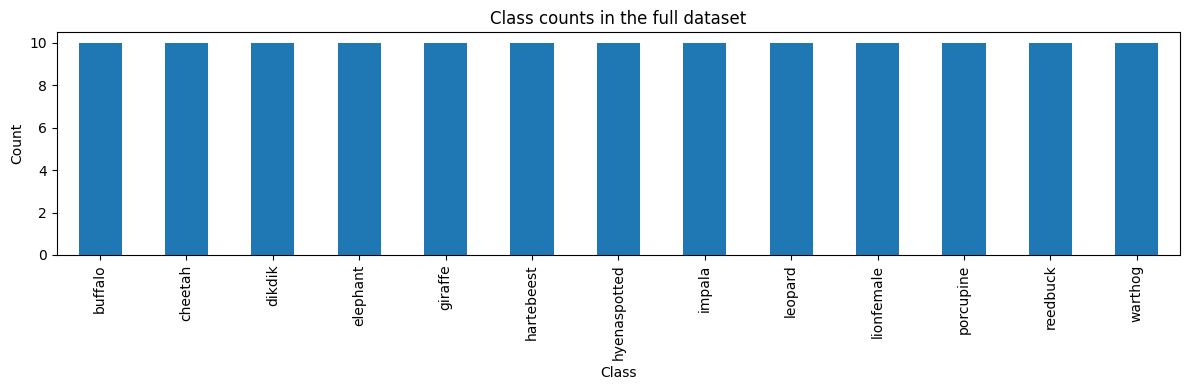

In [3]:
dataset_class_counts = snapshot_split_df["final_label"].value_counts().reindex(species_list, fill_value=0)
display(pd.DataFrame({"class": dataset_class_counts.index, "count": dataset_class_counts.values}))

ax = dataset_class_counts.sort_index().plot(kind="bar", figsize=(12, 4), title="Class counts in the full dataset")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


In [4]:

ALIA_REPO_URL = "https://github.com/lisadunlap/ALIA.git"
ALIA_REPO_PATH = Path("ALIA")


def git(*args: str) -> subprocess.CompletedProcess[str]:
    return subprocess.run(
        ["git", *args],
        capture_output=True,
        text=True,
        check=False,
    )


remote_check = git("ls-remote", ALIA_REPO_URL, "HEAD")
print("ALIA remote status:", remote_check.returncode)
print((remote_check.stdout or remote_check.stderr).splitlines()[:3])

if not ALIA_REPO_PATH.exists():
    clone_check = git("clone", "--depth", "1", ALIA_REPO_URL, str(ALIA_REPO_PATH))
    print("ALIA clone status:", clone_check.returncode)
    if clone_check.returncode != 0:
        print((clone_check.stdout or clone_check.stderr).splitlines()[:10])

if ALIA_REPO_PATH.exists():
    head_check = git("-C", str(ALIA_REPO_PATH), "rev-parse", "HEAD")
    print("ALIA local HEAD:", head_check.returncode, head_check.stdout.strip())

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

from alia_speciesnet_helpers import ALIA_EDIT_SPECS, build_alia_augmentations

print("ALIA edit specs:", [s.name for s in ALIA_EDIT_SPECS])


ALIA remote status: 0
['ce01c941311a6e919a371e31661e83c6d54e9a05\tHEAD']
ALIA local HEAD: 0 ce01c941311a6e919a371e31661e83c6d54e9a05
ALIA edit specs: ['background', 'weather', 'lighting', 'season']


In [5]:

train_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

eval_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)


class LocalAnimalDataset(Dataset):
    def __init__(self, df: pd.DataFrame, species_to_idx: dict[str, int], transform=None):
        self.df = df.reset_index(drop=True)
        self.species_to_idx = species_to_idx
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.species_to_idx[row["final_label"]]


train_combined = pd.concat([snapshot_train, inat_local_df], ignore_index=True)
train_combined.to_csv(NATALIE_ROOT / "train_snapshot_plus_inat.csv", index=False)
snapshot_val.to_csv(NATALIE_ROOT / "val_snapshot_only.csv", index=False)
snapshot_test.to_csv(NATALIE_ROOT / "test_snapshot_only.csv", index=False)

train_dataset = LocalAnimalDataset(train_combined, species_to_idx, transform=train_transform)
val_dataset = LocalAnimalDataset(snapshot_val, species_to_idx, transform=eval_transform)
test_dataset = LocalAnimalDataset(snapshot_test, species_to_idx, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))


Train: 208
Val: 26
Test: 26


In [6]:

def to_speciesnet_format(x: torch.Tensor) -> torch.Tensor:
    return x.permute(0, 2, 3, 1).contiguous()


def get_tensor_output(out):
    if isinstance(out, dict):
        out = list(out.values())[0]
    elif isinstance(out, (list, tuple)):
        out = out[0]
    if out.ndim > 2:
        out = torch.flatten(out, start_dim=1)
    return out


class TinyBackbone(nn.Module):
    def __init__(self, feature_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(64, feature_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


def load_speciesnet_backbone():
    try:
        import kagglehub

        speciesnet_dir = Path(kagglehub.model_download("google/speciesnet/pyTorch/v4.0.2b/1"))
        weight_files = [p for p in speciesnet_dir.rglob("*") if p.is_file()]
        print("SpeciesNet files:", len(weight_files))
        for candidate in weight_files:
            if candidate.suffix.lower() in {".pt", ".pth", ".bin"}:
                try:
                    backbone = torch.load(candidate, map_location=device, weights_only=False)
                    print("Loaded SpeciesNet backbone:", candidate)
                    return backbone, True, candidate
                except Exception as exc:
                    print("Skipping:", candidate.name, exc)
        raise FileNotFoundError("No loadable SpeciesNet weights found.")
    except Exception as exc:
        print("Falling back to TinyBackbone:", exc)
        return TinyBackbone(), False, None


class SpeciesNetAdapter(nn.Module):
    def __init__(self, base_model: nn.Module, num_classes: int, expects_nhwc: bool, freeze_backbone: bool = True):
        super().__init__()
        self.base_model = base_model
        self.expects_nhwc = expects_nhwc
        self.freeze_backbone = freeze_backbone

        with torch.no_grad():
            dummy = torch.zeros(1, 3, 224, 224, device=device)
            dummy_in = to_speciesnet_format(dummy) if self.expects_nhwc else dummy
            features = get_tensor_output(self.base_model(dummy_in))
            if features.ndim > 2:
                features = torch.flatten(features, start_dim=1)
            feature_dim = features.shape[1]

        self.classifier = nn.Linear(feature_dim, num_classes)

    def forward(self, x):
        x = to_speciesnet_format(x) if self.expects_nhwc else x
        if self.freeze_backbone:
            with torch.no_grad():
                features = get_tensor_output(self.base_model(x))
        else:
            features = get_tensor_output(self.base_model(x))
        if features.ndim > 2:
            features = torch.flatten(features, start_dim=1)
        return self.classifier(features)


def fresh_model():
    base_model, expects_nhwc, model_path = load_speciesnet_backbone()
    if hasattr(base_model, "to"):
        base_model = base_model.to(device)
    if hasattr(base_model, "eval"):
        base_model.eval()
    if hasattr(base_model, "parameters"):
        for param in base_model.parameters():
            param.requires_grad = False
    model = SpeciesNetAdapter(base_model, len(species_list), expects_nhwc=expects_nhwc).to(device)
    print("Model path:", model_path)
    return model


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.set_grad_enabled(is_train):
        for x, y in tqdm(loader, leave=False):
            x = x.to(device)
            y = y.to(device)

            if USE_AMP:
                with torch.amp.autocast("cuda", enabled=True):
                    logits = model(x)
                    loss = criterion(logits, y)
            else:
                logits = model(x)
                loss = criterion(logits, y)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                if USE_AMP:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

            total_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(y.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.array(all_preds), np.array(all_labels)


def evaluate_and_save(model, loader, out_prefix: str):
    loss, preds, labels = run_epoch(model, loader, criterion, optimizer=None)
    report = classification_report(
        labels,
        preds,
        target_names=species_list,
        output_dict=True,
        zero_division=0,
    )
    report_path = NATALIE_ROOT / f"{out_prefix}_classification_report.json"
    with open(report_path, "w") as f:
        json.dump(report, f, indent=2)
    cm = confusion_matrix(labels, preds)
    cm_path = NATALIE_ROOT / f"{out_prefix}_confusion_matrix.npy"
    np.save(cm_path, cm)
    print(classification_report(labels, preds, target_names=species_list, zero_division=0))
    print("Saved:", report_path)
    print("Saved:", cm_path)
    return report, cm


criterion = nn.CrossEntropyLoss()


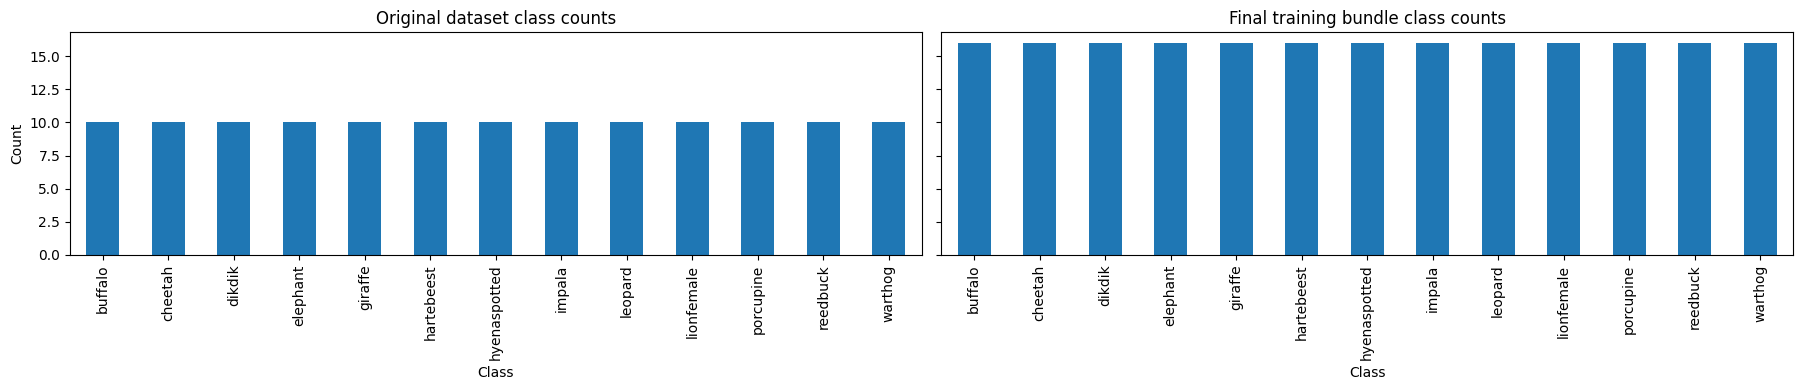

In [7]:
original_counts = snapshot_split_df["final_label"].value_counts().reindex(species_list, fill_value=0)
final_train_counts = train_combined["final_label"].value_counts().reindex(species_list, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 4), sharey=True)
original_counts.sort_index().plot(kind="bar", ax=axes[0], title="Original dataset class counts")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
final_train_counts.sort_index().plot(kind="bar", ax=axes[1], title="Final training bundle class counts")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()


In [8]:

model = fresh_model()
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_HEAD)

for epoch in range(NUM_EPOCHS_HEAD):
    train_loss, _, _ = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, _, _ = run_epoch(model, val_loader, criterion)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS_HEAD}")
    print("Train loss:", train_loss)
    print("Val loss:", val_loss)

for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(model.parameters(), lr=LR_UNFREEZE)
for epoch in range(NUM_EPOCHS_UNFREEZE):
    train_loss, _, _ = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, _, _ = run_epoch(model, val_loader, criterion)
    print(f"Unfreeze epoch {epoch+1}/{NUM_EPOCHS_UNFREEZE}")
    print("Train loss:", train_loss)
    print("Val loss:", val_loss)

finetuned_report, finetuned_cm = evaluate_and_save(
    model,
    test_loader,
    "finetuned_snapshot_plus_inat_smoke"
)

summary_rows = []
for cls in species_list:
    r = finetuned_report[cls]
    summary_rows.append(
        {
            "class": cls,
            "precision": r["precision"],
            "recall": r["recall"],
            "f1": r["f1-score"],
            "support": r["support"],
        }
    )

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(NATALIE_ROOT / "finetuned_per_class_metrics.csv", index=False)
summary_df


SpeciesNet files: 6
Loaded SpeciesNet backbone: C:\Users\carol\.cache\kagglehub\models\google\speciesnet\pyTorch\v4.0.2b\1\full_image_88545560_22x8_v12_epoch_00153.pt
Model path: C:\Users\carol\.cache\kagglehub\models\google\speciesnet\pyTorch\v4.0.2b\1\full_image_88545560_22x8_v12_epoch_00153.pt


Epoch 1/2
Train loss: 25.763019268329327
Val loss: 17.633396442119892


Epoch 2/2
Train loss: 11.229336995344896
Val loss: 7.451243840731108


Unfreeze epoch 1/1
Train loss: 4.329181872881376
Val loss: 3.1497392654418945


              precision    recall  f1-score   support

     buffalo       0.50      0.50      0.50         2
     cheetah       0.12      0.50      0.20         2
      dikdik       0.00      0.00      0.00         2
    elephant       0.00      0.00      0.00         2
     giraffe       0.00      0.00      0.00         2
  hartebeest       0.00      0.00      0.00         2
hyenaspotted       0.00      0.00      0.00         2
      impala       0.00      0.00      0.00         2
     leopard       0.00      0.00      0.00         2
  lionfemale       0.00      0.00      0.00         2
   porcupine       0.00      0.00      0.00         2
    reedbuck       0.20      1.00      0.33         2
     warthog       0.00      0.00      0.00         2

    accuracy                           0.15        26
   macro avg       0.06      0.15      0.08        26
weighted avg       0.06      0.15      0.08        26

Saved: c:\dev\cs159\artifacts\week2_natalie_speciesnet_smoke\finetuned_snapshot

,class,precision,recall,f1,support
0,buffalo,0.500,0.5,0.500000,2.0
1,cheetah,0.125,0.5,0.200000,2.0
2,dikdik,0.000,0.0,0.000000,2.0
3,elephant,0.000,0.0,0.000000,2.0
4,giraffe,0.000,0.0,0.000000,2.0
5,hartebeest,0.000,0.0,0.000000,2.0
6,hyenaspotted,0.000,0.0,0.000000,2.0
7,impala,0.000,0.0,0.000000,2.0
8,leopard,0.000,0.0,0.000000,2.0
9,lionfemale,0.000,0.0,0.000000,2.0


In [9]:

ALIA_EXPERIMENT_ROOT = NATALIE_ROOT / "alia_experiments"
ALIA_CACHE_ROOT = ALIA_EXPERIMENT_ROOT / "snapshot_cache"
ALIA_GENERATED_ROOT = ALIA_EXPERIMENT_ROOT / "generated"
ALIA_EXPERIMENT_ROOT.mkdir(parents=True, exist_ok=True)
ALIA_CACHE_ROOT.mkdir(parents=True, exist_ok=True)
ALIA_GENERATED_ROOT.mkdir(parents=True, exist_ok=True)

ALIA_METHODS = ALIA_EDIT_SPECS
alia_results = []

for spec in ALIA_METHODS:
    print(f"\nRunning ALIA method: {spec.name}")
    method_generated_root = ALIA_GENERATED_ROOT / spec.name
    method_generated_root.mkdir(parents=True, exist_ok=True)

    aug_df = build_alia_augmentations(
        source_df=snapshot_train,
        output_root=method_generated_root,
        repo_path=ALIA_REPO_PATH if ALIA_REPO_PATH.exists() else Path("."),
        max_images_per_class=ALIA_MAX_IMAGES_PER_CLASS,
        methods=[spec],
    )

    if aug_df.empty:
        print(f"No ALIA images were generated for {spec.name}; skipping.")
        continue

    train_df = pd.concat([snapshot_train, inat_local_df, aug_df], ignore_index=True)
    train_df.to_csv(NATALIE_ROOT / f"alia_train_bundle_{spec.name}.csv", index=False)

    train_dataset = LocalAnimalDataset(train_df, species_to_idx, transform=train_transform)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

    alia_model = fresh_model()
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, alia_model.parameters()), lr=LR_HEAD)

    for epoch in range(NUM_EPOCHS_HEAD):
        train_loss, _, _ = run_epoch(alia_model, train_loader, criterion, optimizer)
        val_loss, _, _ = run_epoch(alia_model, val_loader, criterion)
        print(f"{spec.name} epoch {epoch+1}/{NUM_EPOCHS_HEAD} - train {train_loss:.4f} - val {val_loss:.4f}")

    for param in alia_model.parameters():
        param.requires_grad = True

    optimizer = torch.optim.AdamW(alia_model.parameters(), lr=LR_UNFREEZE)
    for epoch in range(NUM_EPOCHS_UNFREEZE):
        train_loss, _, _ = run_epoch(alia_model, train_loader, criterion, optimizer)
        val_loss, _, _ = run_epoch(alia_model, val_loader, criterion)
        print(f"{spec.name} unfreeze epoch {epoch+1}/{NUM_EPOCHS_UNFREEZE} - train {train_loss:.4f} - val {val_loss:.4f}")

    report_prefix = f"alia_{spec.name}_snapshot_plus_inat_plus_diffusion_smoke"
    report, cm = evaluate_and_save(alia_model, test_loader, report_prefix)
    macro = report["macro avg"]
    weighted = report["weighted avg"]
    alia_results.append(
        {
            "method": spec.name,
            "num_generated": len(aug_df),
            "macro_precision": macro["precision"],
            "macro_recall": macro["recall"],
            "macro_f1": macro["f1-score"],
            "weighted_precision": weighted["precision"],
            "weighted_recall": weighted["recall"],
            "weighted_f1": weighted["f1-score"],
        }
    )

alia_results_df = pd.DataFrame(alia_results).sort_values("weighted_f1", ascending=False)
alia_results_df.to_csv(NATALIE_ROOT / "alia_method_comparison.csv", index=False)
alia_results_df



Running ALIA method: background


SpeciesNet files: 6
Loaded SpeciesNet backbone: C:\Users\carol\.cache\kagglehub\models\google\speciesnet\pyTorch\v4.0.2b\1\full_image_88545560_22x8_v12_epoch_00153.pt
Model path: C:\Users\carol\.cache\kagglehub\models\google\speciesnet\pyTorch\v4.0.2b\1\full_image_88545560_22x8_v12_epoch_00153.pt


background epoch 1/2 - train 27.8927 - val 26.7265


background epoch 2/2 - train 20.4093 - val 13.4963


background unfreeze epoch 1/1 - train 6.7316 - val 3.7645


...

season epoch 1/2 - train 31.4270 - val 13.0831


season epoch 2/2 - train 10.9740 - val 8.6717


season unfreeze epoch 1/1 - train 5.2638 - val 3.2691


              precision    recall  f1-score   support

     buffalo       0.00      0.00      0.00         2
     cheetah       0.00      0.00      0.00         2
      dikdik       0.00      0.00      0.00         2
    elephant       0.00      0.00      0.00         2
     giraffe       0.07      0.50      0.12         2
  hartebeest       0.00      0.00      0.00         2
hyenaspotted       0.00      0.00      0.00         2
      impala       0.00      0.00      0.00         2
     leopard       0.00      0.00      0.00         2
  lionfemale       0.20      0.50      0.29         2
   porcupine       0.00      0.00      0.00         2
    reedbuck       0.00      0.00      0.00         2
     warthog       0.00      0.00      0.00         2

    accuracy                           0.08        26
   macro avg       0.02      0.08      0.03        26
weighted avg       0.02      0.08      0.03        26

Saved: c:\dev\cs159\artifacts\week2_natalie_speciesnet_smoke\alia_season_snapsh

,method,num_generated,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,background,13,0.030220,0.076923,0.042735,0.030220,0.076923,0.042735
1,weather,13,0.029138,0.076923,0.037179,0.029138,0.076923,0.037179
3,season,13,0.020879,0.076923,0.031593,0.020879,0.076923,0.031593
2,lighting,13,0.006154,0.076923,0.011396,0.006154,0.076923,0.011396
